# Segmentacion Futbolistas

In [2]:
import numpy as np 
import pandas as pd 
np.random.seed(42)

In [3]:
# Ruta corregida con raw string (evita que Python interprete \U, \p, etc. como escapes)
ruta_jugadores = r"jugadores_futbol.xlsx"

df_jugadores = pd.read_excel(ruta_jugadores)

display(df_jugadores)

,Velocidad,Tiro,Regate,Pase,Defensa,Físico,Posicion_Real
0,68.476999,39.032150,54.533820,75.661209,83.360926,78.361041,Defensa
1,76.054490,45.372043,46.713679,68.797920,81.756076,76.739892,Defensa
2,66.693736,26.607038,37.925575,61.063987,77.910182,82.199731,Defensa
3,58.643831,30.113874,60.259541,63.419566,85.472697,70.026763,Defensa
4,61.189321,40.776458,41.943045,67.629886,80.795529,77.958144,Defensa
...,...,...,...,...,...,...,...
795,85.091098,74.151161,88.873526,70.116287,21.078106,69.695779,Delantero
796,84.854603,87.214707,78.428377,50.939777,36.674503,66.749382,Delantero
797,74.855970,74.129003,99.000000,68.166336,39.385754,61.096041,Delantero
798,72.458183,78.978451,83.406373,67.600731,34.312155,66.585610,Delantero


In [6]:
# Escalado y entrenamiento

from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler

# Nombres de columnas como strings (antes eran variables sin definir → NameError)
features = ['Velocidad', 'Tiro', 'Regate', 'Pase', 'Defensa', 'Físico']

# Seleccionamos directamente las columnas del DataFrame ya cargado
df = df_jugadores[features].copy()

# .values es un atributo, no un método → sin paréntesis
X = df[features].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Datos escalados: {X_scaled.shape[0]} jugadores × {X_scaled.shape[1]} variables")
print(f"   Rango tras escalado → min: {X_scaled.min():.2f}, max: {X_scaled.max():.2f}")

✅ Datos escalados: 800 jugadores × 6 variables
   Rango tras escalado → min: 0.00, max: 1.00


In [7]:
#Inicializar  red 10x10 para 6 variables


som_grid_rows = 10
som_grid_cols = 10
som = MiniSom(x=som_grid_rows, y = som_grid_cols, input_len=6,
              sigma=1.5, learning_rate=0.5, neighborhood_function='gaussian', random_seed=42)

In [10]:
# Entrenar la red

# Inicialización con PCA: coloca los pesos iniciales de la red siguiendo
# las dos componentes principales de los datos → el entrenamiento converge más rápido
som.pca_weights_init(X_scaled)

som.train_random(data=X_scaled, num_iteration=5000, verbose=True)

 [ 5000 / 5000 ] 100% - 0:00:00 left 
 quantization error: 0.1458669534034383


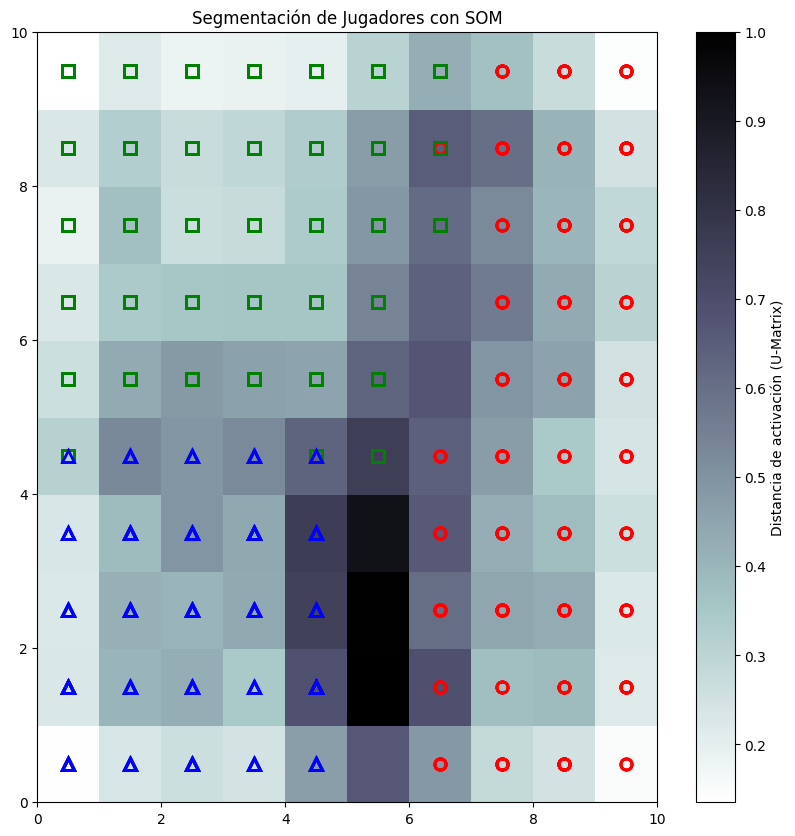

In [12]:
# Visualización

import matplotlib.pyplot as plt

%matplotlib inline

df = df_jugadores[features + ["Posicion_Real"]]

plt.figure(figsize=(10, 10))

# Dibujar la U-Matrix (distancia entre neuronas)
plt.pcolor(
    som.distance_map().T,
    cmap="bone_r"
)

plt.colorbar(
    label="Distancia de activación (U-Matrix)"
)

# Marcadores para verificar el acierto visualmente
markers = ["o", "s", "^"]
colors = ["r", "g", "b"]

label_map = {
    "Defensa": 0,
    "Centrocampista": 1,
    "Delantero": 2
}

for cnt, x in enumerate(X_scaled):
    # Neurona ganadora para este jugador
    w = som.winner(x)

    # Colocar el marcador en el centro de la celda
    plt.plot(
        w[0] + 0.5,
        w[1] + 0.5,
        markers[label_map[df["Posicion_Real"].iloc[cnt]]],
        markerfacecolor="none",
        markeredgecolor=colors[label_map[df["Posicion_Real"].iloc[cnt]]],
        markersize=8,
        markeredgewidth=2
    )

plt.title("Segmentación de Jugadores con SOM")
plt.show()

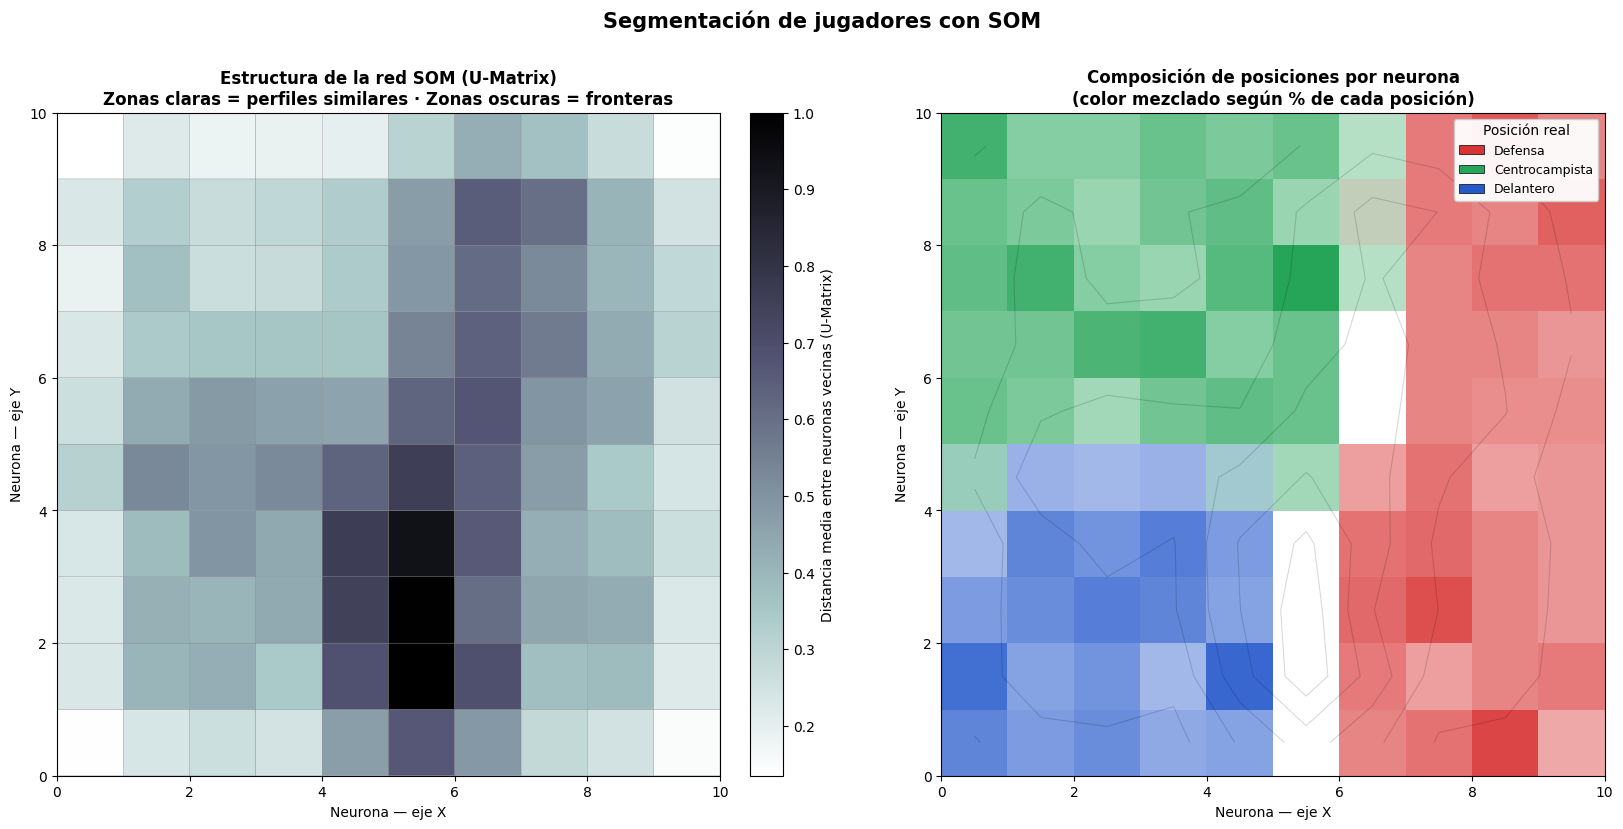

In [14]:
# ============================================================
# Visualización mejorada — Mapa de composición de clase por neurona
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

label_map = {
    "Defensa": 0,
    "Centrocampista": 1,
    "Delantero": 2,
}
colores_clase = {
    "Defensa":        np.array([0.85, 0.20, 0.20]),   # rojo
    "Centrocampista": np.array([0.15, 0.65, 0.35]),   # verde
    "Delantero":      np.array([0.15, 0.35, 0.80]),   # azul
}

n_x, n_y = som.get_weights().shape[:2]

# 1. Contamos, para cada neurona, cuántos jugadores de cada clase caen en ella
conteo = np.zeros((n_x, n_y, 3))
for i, x in enumerate(X_scaled):
    w = som.winner(x)
    clase = df_jugadores["Posicion_Real"].iloc[i]
    conteo[w[0], w[1], label_map[clase]] += 1

total_por_neurona = conteo.sum(axis=2, keepdims=True)
total_safe = np.where(total_por_neurona == 0, 1, total_por_neurona)
proporciones = conteo / total_safe  # % de cada clase por neurona

# 2. Mezclamos los colores según la proporción de cada clase (RGB blending)
rgb_map = np.ones((n_x, n_y, 3))  # blanco = neurona vacía
for i in range(n_x):
    for j in range(n_y):
        if total_por_neurona[i, j, 0] > 0:
            rgb_map[i, j] = sum(
                proporciones[i, j, label_map[c]] * colores_clase[c]
                for c in label_map
            )

# 3. Modulamos la saturación por densidad (neuronas con pocos jugadores → más pálidas)
densidad = total_por_neurona[:, :, 0]
densidad_norm = densidad / densidad.max() if densidad.max() > 0 else densidad
alpha = 0.25 + 0.75 * densidad_norm
rgb_final = rgb_map * alpha[:, :, None] + (1 - alpha[:, :, None]) * 1.0

# ============================================================
# Figura combinada: U-Matrix + Mapa de composición
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(17, 8))

# --- Panel 1: U-Matrix (estructura de la red) ---
u_matrix = som.distance_map().T
im0 = axes[0].pcolor(u_matrix, cmap="bone_r", edgecolors="grey", linewidths=0.2)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04,
             label="Distancia media entre neuronas vecinas (U-Matrix)")
axes[0].set_title("Estructura de la red SOM (U-Matrix)\n"
                   "Zonas claras = perfiles similares · Zonas oscuras = fronteras",
                   fontsize=12, fontweight="bold")
axes[0].set_xlabel("Neurona — eje X")
axes[0].set_ylabel("Neurona — eje Y")
axes[0].set_aspect("equal")

# --- Panel 2: Composición de clase por neurona ---
axes[1].imshow(np.transpose(rgb_final, (1, 0, 2)), origin="lower", extent=[0, n_x, 0, n_y])
axes[1].contour(
    np.arange(n_x) + 0.5, np.arange(n_y) + 0.5, u_matrix,
    levels=6, colors="black", alpha=0.15, linewidths=0.8
)
axes[1].set_title("Composición de posiciones por neurona\n"
                   "(color mezclado según % de cada posición)",
                   fontsize=12, fontweight="bold")
axes[1].set_xlabel("Neurona — eje X")
axes[1].set_ylabel("Neurona — eje Y")
axes[1].set_aspect("equal")

parches = [
    plt.Rectangle((0, 0), 1, 1, facecolor=colores_clase[c],
                  edgecolor="black", linewidth=0.5, label=c)
    for c in label_map
]
axes[1].legend(handles=parches, title="Posición real", loc="upper right",
               framealpha=0.95, fontsize=9, title_fontsize=10)

plt.suptitle("Segmentación de jugadores con SOM", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

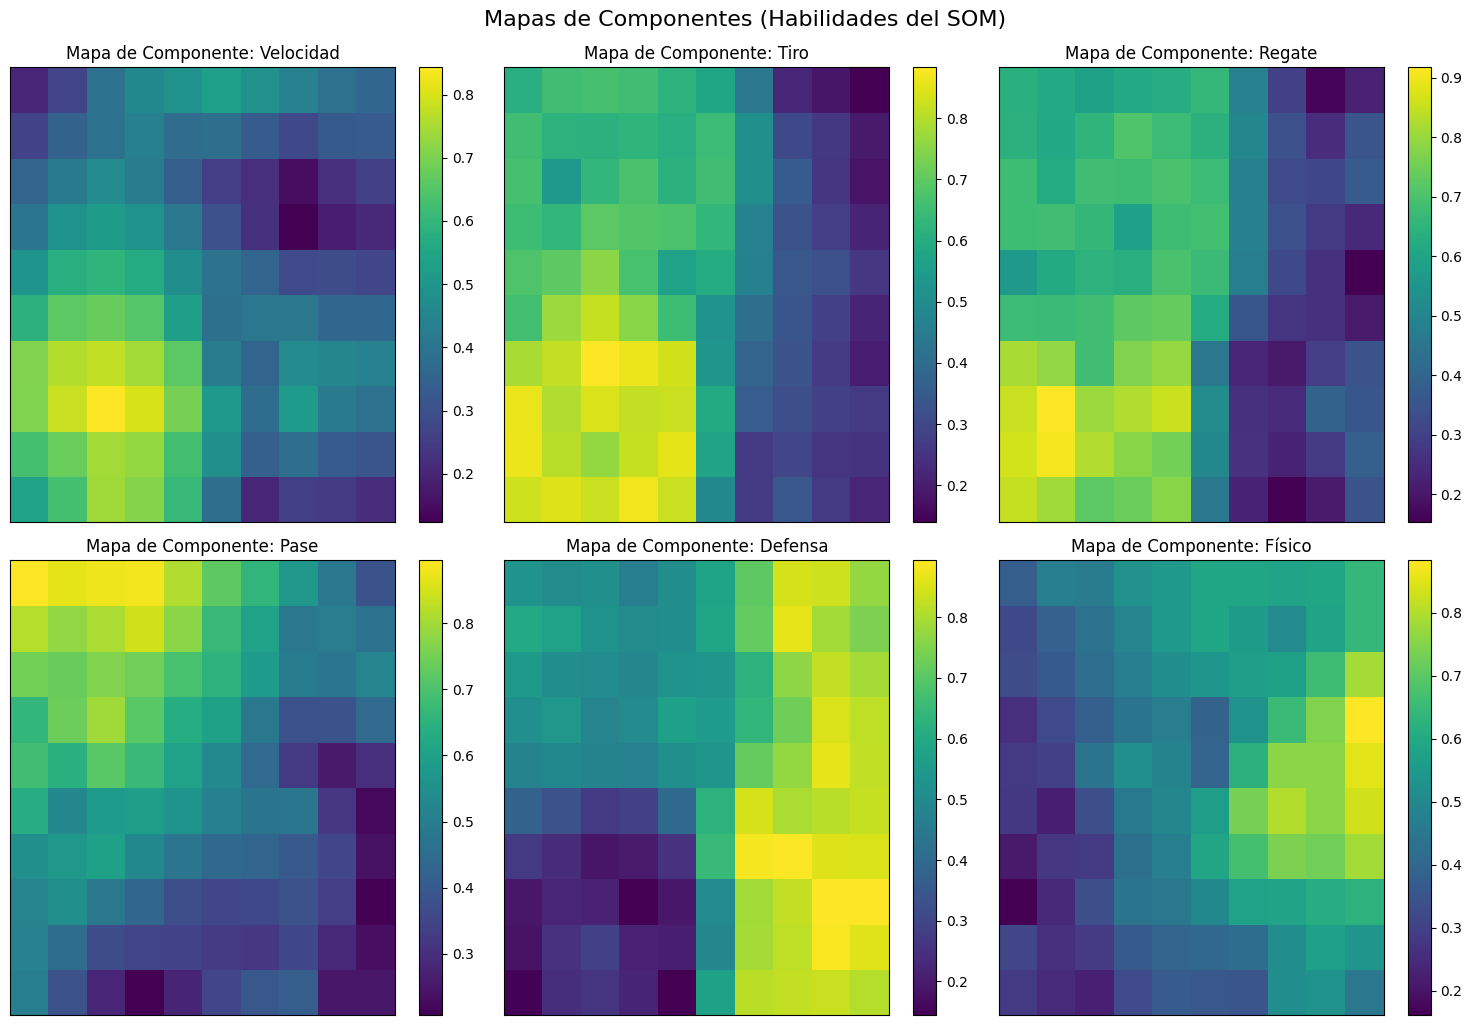

In [15]:
import matplotlib.pyplot as plt

# Obtener los pesos de las neuronas. Forma: (10, 10, 6)
weights = som.get_weights()

# Configurar una cuadrícula de gráficos (2 filas, 3 columnas para las 6 variables)
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 10)
)

# Aplanar la matriz de ejes para iterar fácilmente
axes = axes.ravel()

# Iterar sobre cada una de las 6 habilidades
for i, feature_name in enumerate(features):
    # Extraer el peso del componente 'i' para todas las neuronas (matriz 10x10)
    component_map = weights[:, :, i].T

    # Dibujar el mapa en su respectivo subgráfico
    im = axes[i].pcolor(
        component_map,
        cmap="viridis"  # Amarillo = valor alto, morado = valor bajo
    )

    axes[i].set_title(
        f"Mapa de Componente: {feature_name}",
        fontsize=12
    )

    # Añadir barra de color a cada mapa para ver la escala
    fig.colorbar(
        im,
        ax=axes[i]
    )

    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.tight_layout()

plt.suptitle(
    "Mapas de Componentes (Habilidades del SOM)",
    fontsize=16,
    y=1.02
)

plt.show()